# Telco Customer Churn EDA
Exploratory data analysis for the IBM Telco Customer Churn dataset.

In [45]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


## Load dataset

In [46]:
# Load the Telco customer churn dataset
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Check for missing values

In [47]:
# Convert TotalCharges to numeric and identify missing values
# Looking at the data, some fields are blank in `TotalCharges`.
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

`TotalCharges` has 11 blank fields. So, this data requires some cleaning as well.

## Data Cleaning
- Partner, PaperlessBilling, and Churn converted to integers (1 for Yes, 0 for No).
- TotalCharges contained blanks for 11 customers with tenure 0 (less than a month); these rows were removed because it causes inconsequential impact in the dataset.

In [48]:
# Encode binary 'Yes/No' columns and remove rows with missing TotalCharges
yes_no_cols = ['Partner','PaperlessBilling','Churn']
le = LabelEncoder()
for col in yes_no_cols:
    df[col] = le.fit_transform(df[col])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
rows_before = df.shape[0]
df = df.dropna(subset=['TotalCharges'])
rows_after = df.shape[0]
print(f'Dropped {rows_before-rows_after} rows due to missing TotalCharges')


Dropped 11 rows due to missing TotalCharges


### Feature engineering for service columns

- Combine phone service and multiple line service into a single categorical feature.
- Normalize InternetService-related columns and encode them as flags.


In [49]:
# Feature engineering for phone and internet service columns
# Consolidate phone and multiple line services into one column
df['PhoneService'] = df.apply(
    lambda row: 'Multiple' if row['MultipleLines'] == 'Yes'
    else ('1' if row['PhoneService'] == 'Yes' else '0'),
    axis=1
)
df.drop(columns=['MultipleLines'], inplace=True)

# Standardize InternetService categories and convert dependent services to flags
df['InternetService'] = df['InternetService'].replace('No', 'No internet service')
internet_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                 'TechSupport','StreamingTV','StreamingMovies']
for col in internet_cols:
    df[col] = df.apply(
        lambda row: 0 if row['InternetService'] == 'No internet service'
        else (1 if row[col] == 'Yes' else 0),
        axis=1
    )

## Summary statistics


In [50]:
# Summary statistics for numerical columns
stats = df[['tenure','MonthlyCharges','TotalCharges']].agg(['count','mean','median','std','min','max'])
stats.loc['mode'] = df[['tenure','MonthlyCharges','TotalCharges']].mode().iloc[0]
stats

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,No,1,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,No,34,1,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,No,2,1,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,No,45,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,No,2,1,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


## Exploratory Data Analysis

### Gender and Churn Distributions

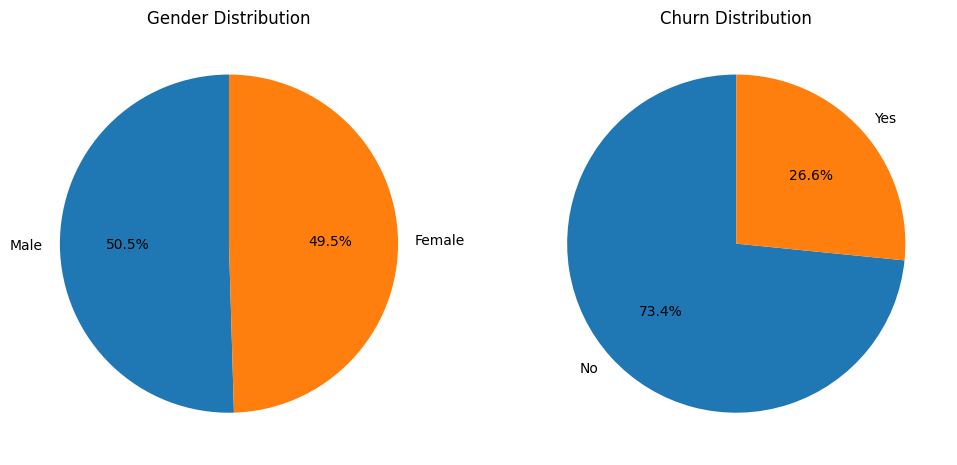

In [51]:
# Visualize gender distribution and churn ratio
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].pie(df['gender'].value_counts(), labels=df['gender'].value_counts().index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Gender Distribution')
axes[1].pie(df['Churn'].value_counts(), labels=['No','Yes'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Distribution')
plt.show()


### Customer contract distribution

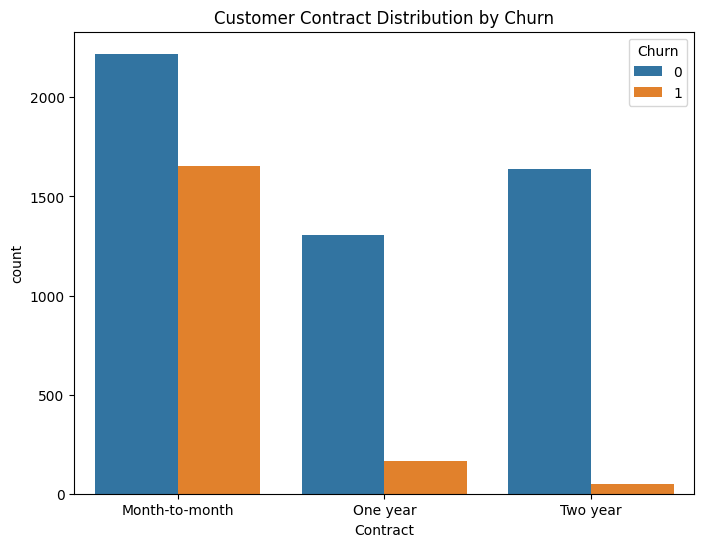

In [52]:
# Examine contract types by churn outcome
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Customer Contract Distribution by Churn')
plt.show()


### Payment method distribution

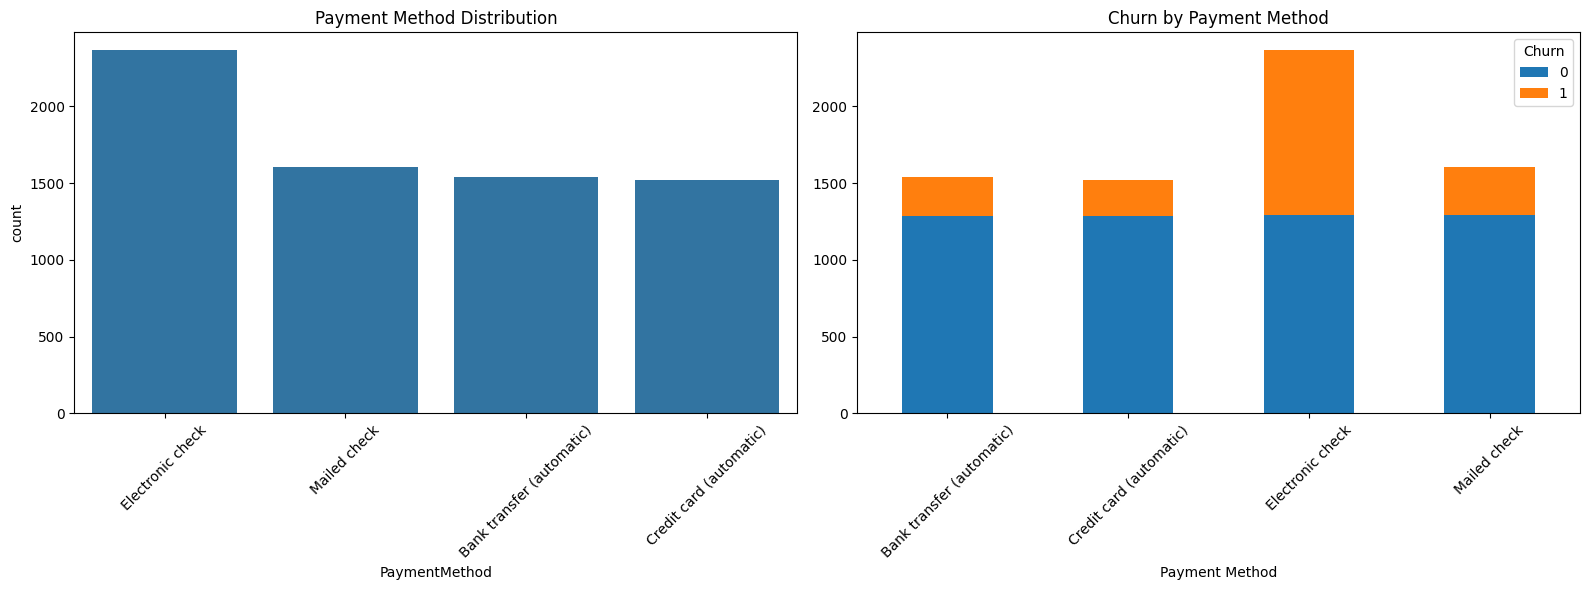

In [53]:
# Analyze distribution of payment methods and churn
order = df['PaymentMethod'].value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.countplot(ax=axes[0], data=df, x='PaymentMethod', order=order)
axes[0].set_title('Payment Method Distribution')
axes[0].tick_params(axis='x', rotation=45)
ct = pd.crosstab(df['PaymentMethod'], df['Churn'])
ct.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Churn by Payment Method')
axes[1].set_xlabel('Payment Method')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Churn')
plt.tight_layout()
plt.show()


### Dependents and Partners

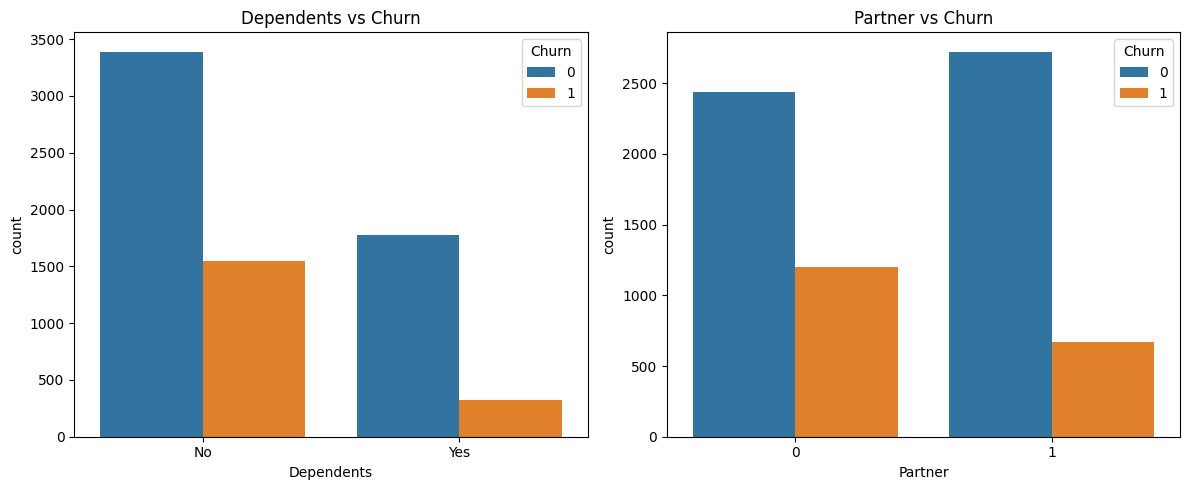

In [54]:
# Explore relationships between dependents, partners, and churn
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(ax=axes[0], data=df, x='Dependents', hue='Churn')
axes[0].set_title('Dependents vs Churn')
sns.countplot(ax=axes[1], data=df, x='Partner', hue='Churn')
axes[1].set_title('Partner vs Churn')
plt.tight_layout()
plt.show()


### Services and Churn

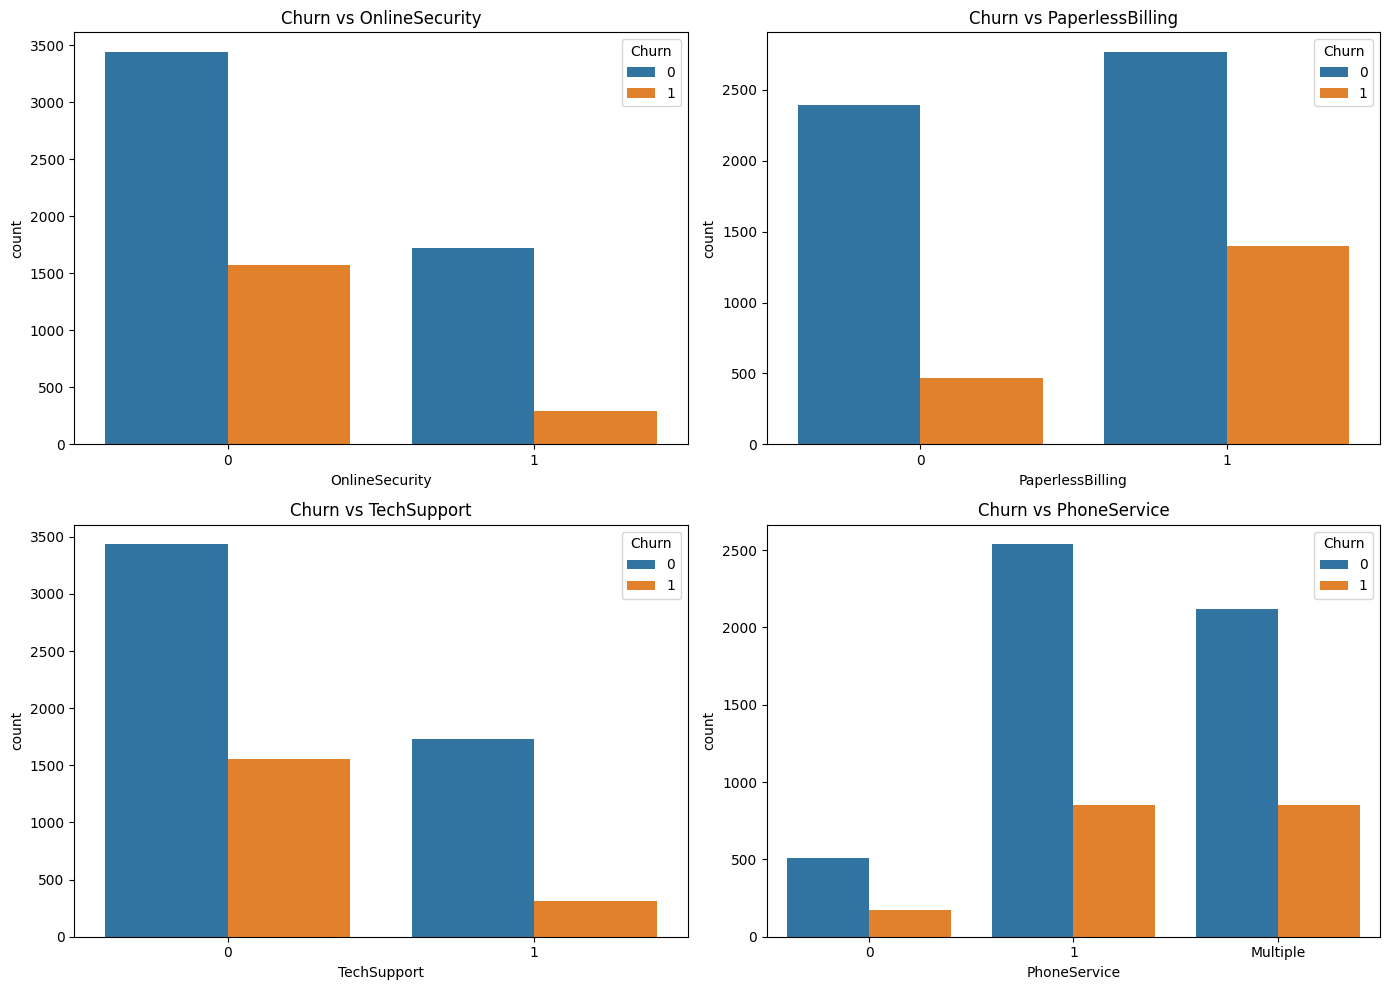

In [55]:
# Compare churn rates across various service subscriptions
services = ['OnlineSecurity', 'PaperlessBilling', 'TechSupport', 'PhoneService']
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, service in zip(axes.flatten(), services):
    sns.countplot(ax=ax, data=df, x=service, hue='Churn')
    ax.set_title(f'Churn vs {service}')
plt.tight_layout()
plt.show()


### Charges and Tenure

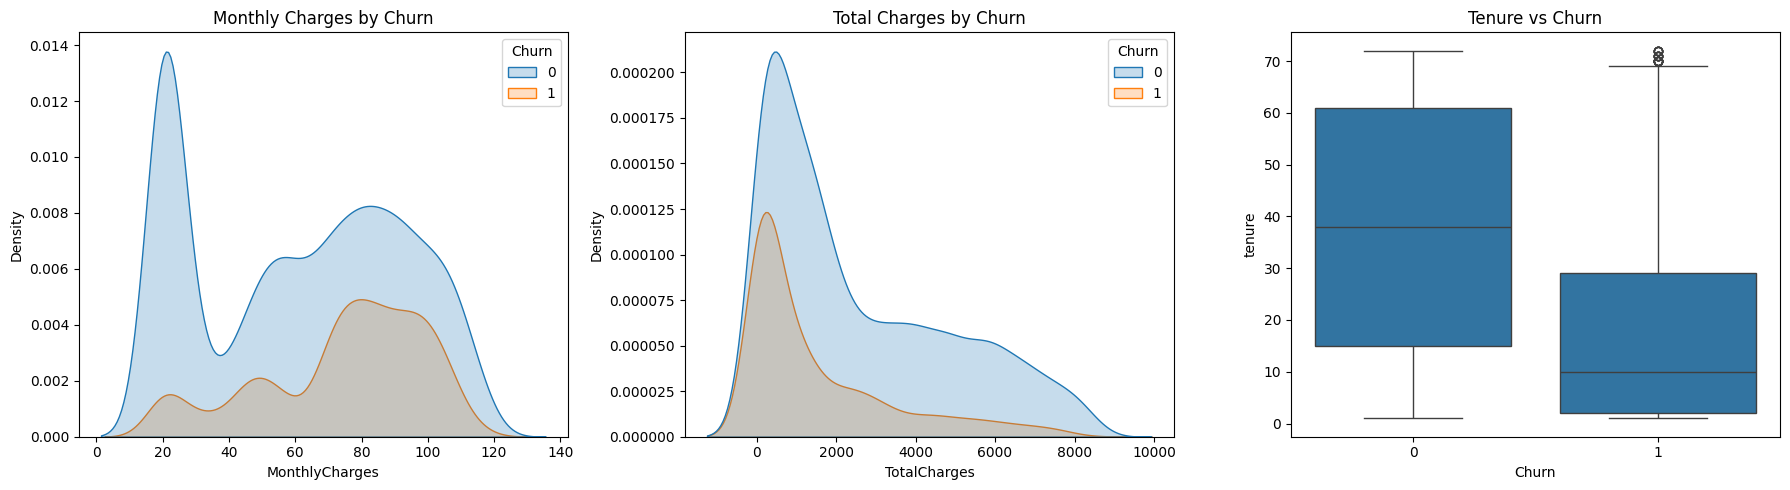

In [56]:
# Investigate charges and tenure against churn
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, ax=axes[0])
axes[0].set_title('Monthly Charges by Churn')
sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True, ax=axes[1])
axes[1].set_title('Total Charges by Churn')
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[2])
axes[2].set_title('Tenure vs Churn')
plt.tight_layout()
plt.show()


### Correlation Heatmap

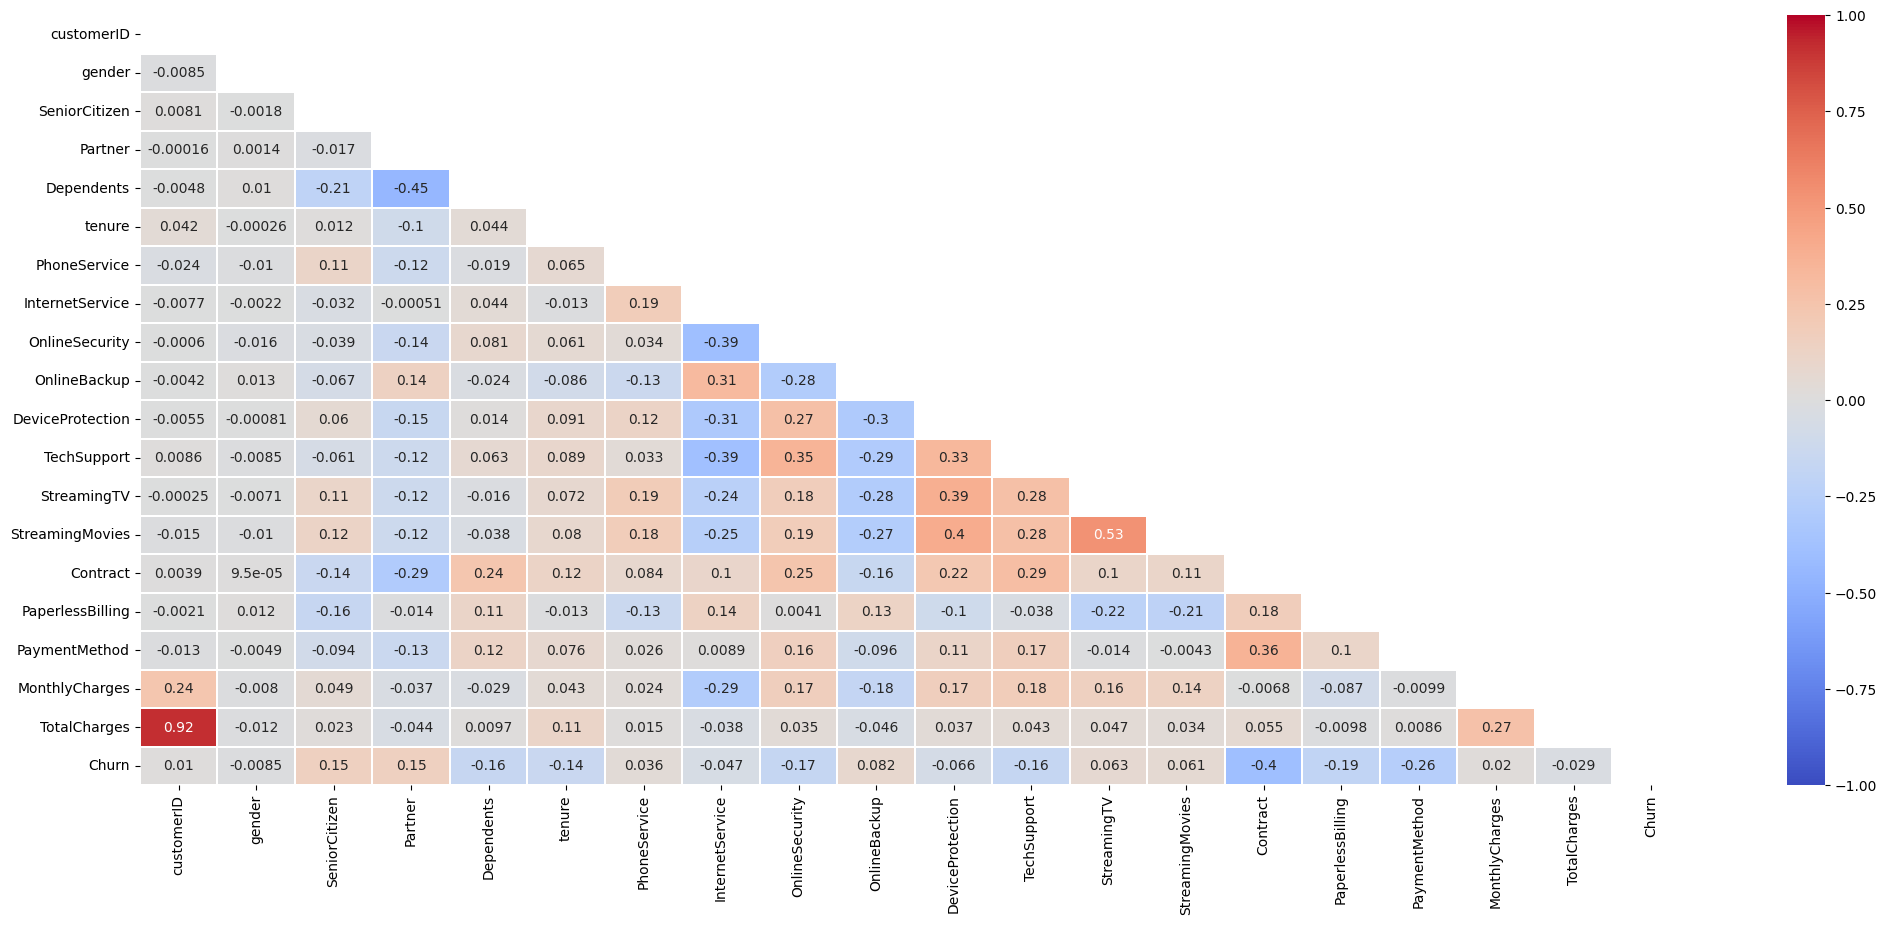

In [57]:
# Display correlation heatmap to inspect feature relationships
plt.figure(figsize=(25, 10))
corr = df.apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

## Summary of useful plots

- **Crosstab / stacked bar**: categorical vs churn (gender, contract, payment, internet service).
- **Regplot / scatter**: numeric vs churn (monthly charges, tenure, total charges).
- **Box/violin plots**: numeric distributions by churn group.
- **Heatmaps**: churn proportions across service categories.

Below are example charts for each plot type.


### Crosstab / stacked bar example


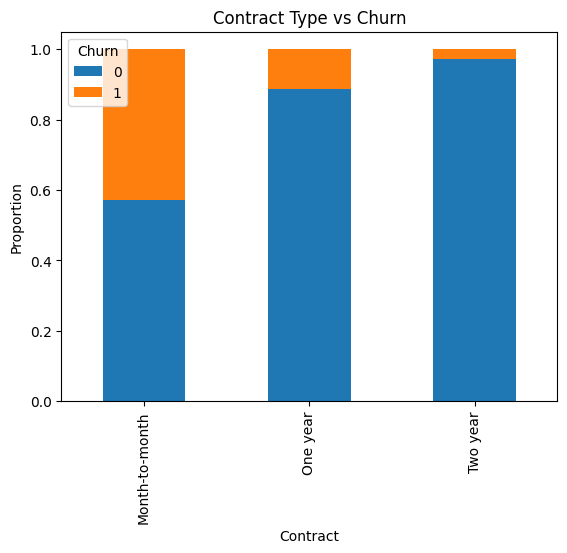

In [58]:
# Example of crosstab/stacked bar for contract type vs churn
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
contract_churn.div(contract_churn.sum(1), axis=0).plot(kind='bar', stacked=True)
plt.title('Contract Type vs Churn')
plt.ylabel('Proportion')
plt.show()


### Regplot examples for numeric features vs churn


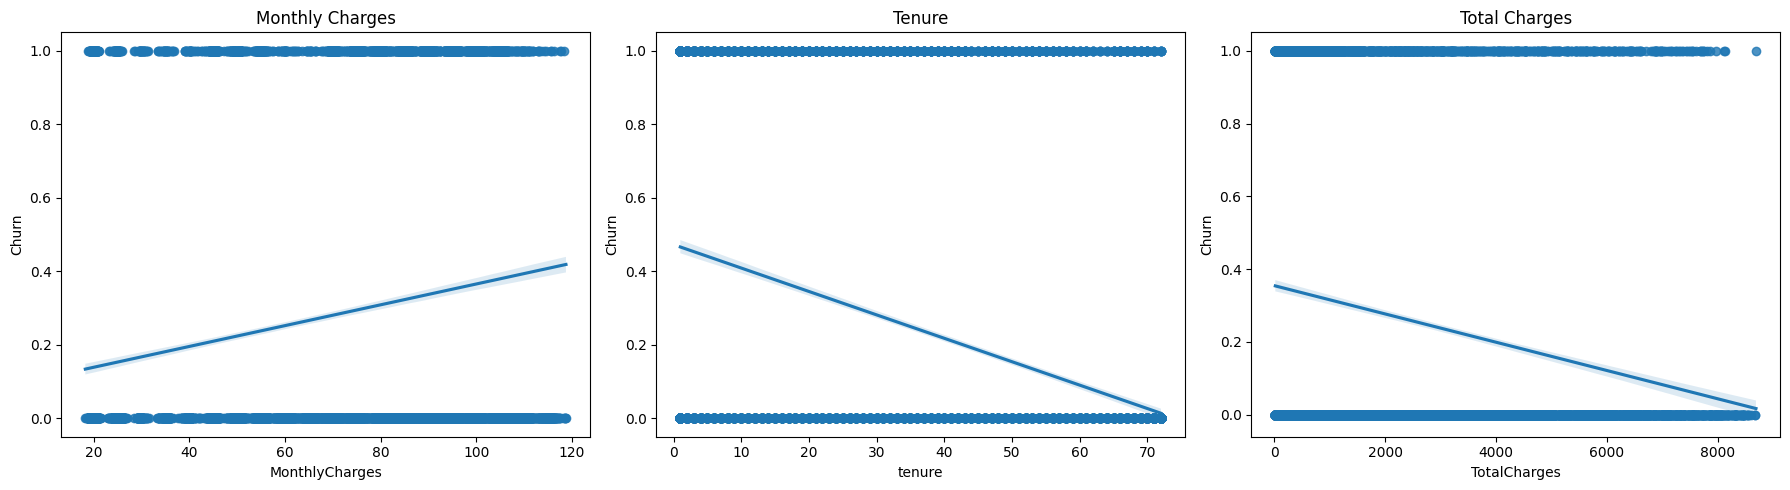

In [59]:
# Regression plots for numeric features vs churn
fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.regplot(x='MonthlyCharges', y='Churn', data=df, ax=axes[0])
sns.regplot(x='tenure', y='Churn', data=df, ax=axes[1])
sns.regplot(x='TotalCharges', y='Churn', data=df, ax=axes[2])
axes[0].set_title('Monthly Charges')
axes[1].set_title('Tenure')
axes[2].set_title('Total Charges')
plt.tight_layout()
plt.show()


### Box plots by churn group


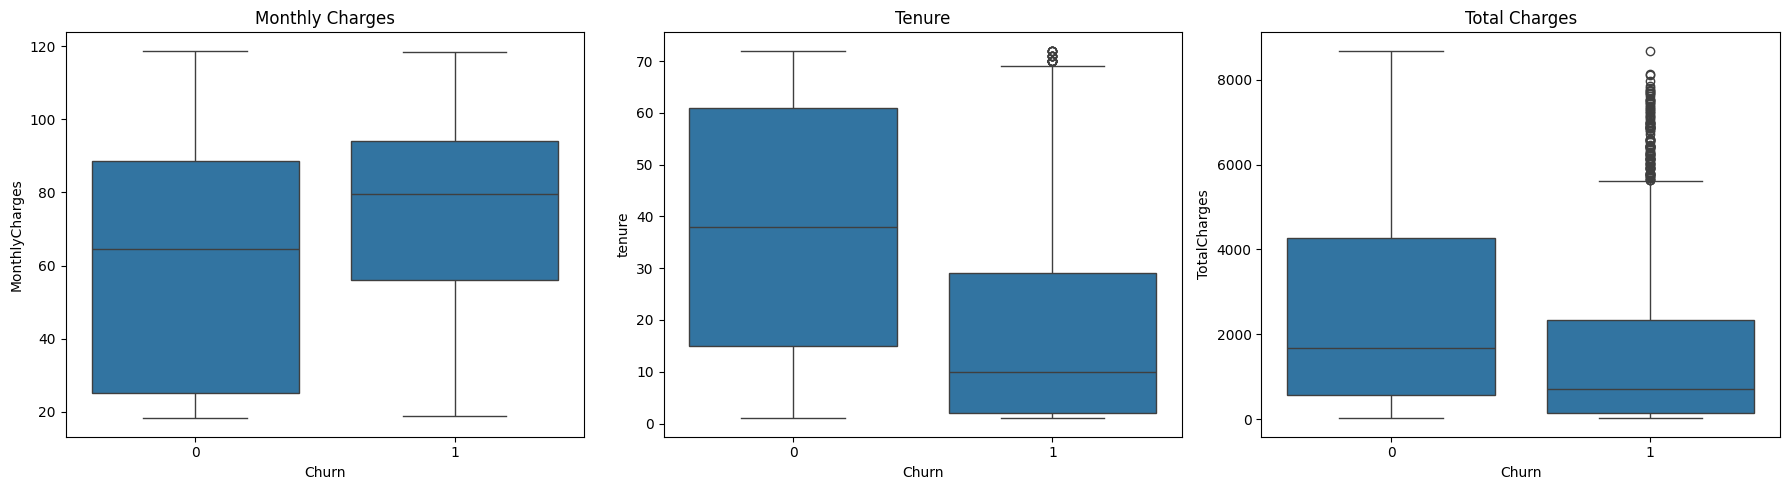

In [60]:
# Box plots showing distribution of numeric features by churn
fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[0])
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1])
sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2])
axes[0].set_title('Monthly Charges')
axes[1].set_title('Tenure')
axes[2].set_title('Total Charges')
plt.tight_layout()
plt.show()


### Heatmap of service-related churn rates


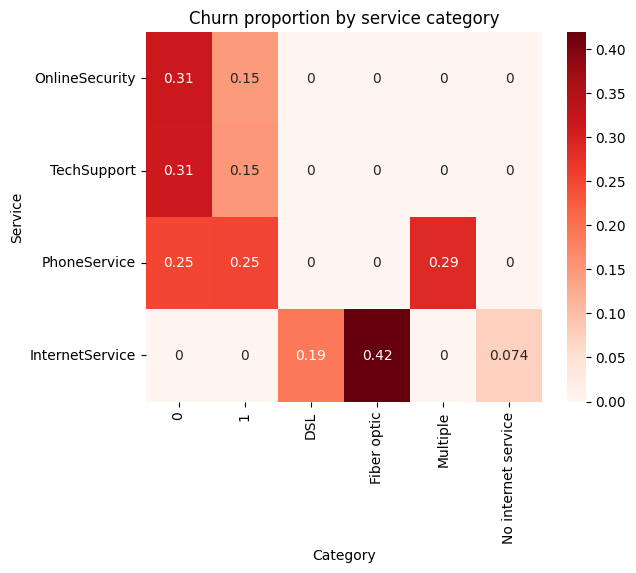

In [61]:
# Heatmap of churn rates across service categories
services = ['OnlineSecurity','TechSupport','PhoneService','InternetService']
# Compute average churn for each service category and arrange as matrix
heatmap_data = pd.DataFrame({
    feature: df.groupby(feature)['Churn'].mean().rename(lambda x: str(x))
    for feature in services
}).T.fillna(0)
sns.heatmap(heatmap_data, annot=True, cmap='Reds')
plt.title('Churn proportion by service category')
plt.ylabel('Service')
plt.xlabel('Category')
plt.show()
